# Calcium Aluminosilicate Glass Simulation with Pedone Potential

Simulation using the parameters from Pedone JPCB 2006 (DSF is used for Coulomb as well).
Used a small sample with a 100 molecules; the number of steps is reduced a lot for testing purposes and not to be used in a real simulation. 

The number of atoms and box size are calculated automatically from the composition and density.

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from pyiron_base import Project

In [14]:
from pyiron_glass import (
    melt_quench_simulation,
    generate_potential,
    get_ase_structure,
    get_structure_dict,
)

In [15]:
pr = Project("test")
atoms_dict = get_structure_dict(
    comp="0.25CaO-0.25Al2O3-0.50SiO2", 
    n_molecules=200, 
    density=2.69*1.0, 
    min_distance=1.8, 
    max_attempts_per_atom = 10000,
    pyiron_project=pr,
)
structure = get_ase_structure(atoms_dict=atoms_dict, pyiron_project=pr,)
potential = generate_potential(atoms_dict=atoms_dict, pyiron_project=pr,)

In [16]:
delayed = melt_quench_simulation(
    structure=structure, 
    potential=potential,
    temperature_high=5000,
    temperature_low=200,
    n_print=1000,
    working_directory="lmp_tmp_directory",
    heating_rate=int(1e14),
    cooling_rate=int(1e14),
    pyiron_project=pr,
)

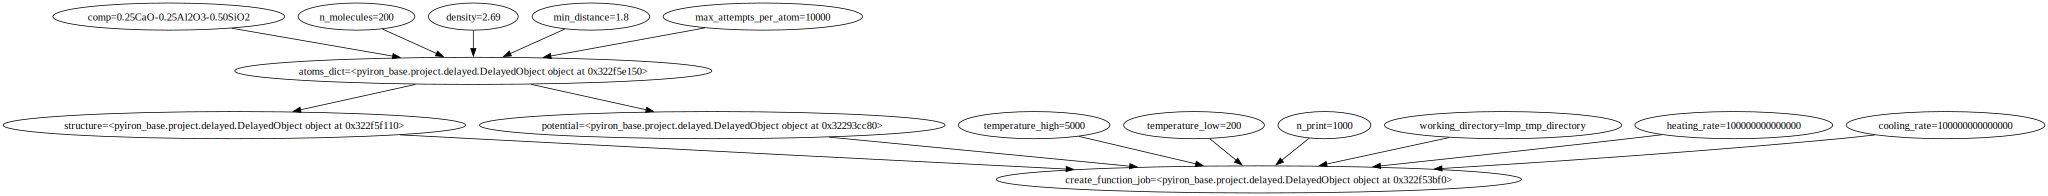

In [17]:
delayed.draw()

In [18]:
result = delayed.pull() 

The job get_ase_structure_32e0198a0681ed25ebf6ad2d92751f1b was saved and received the ID: 604
The job generate_potential_c34990616df3359fc6761eb844449c06 was saved and received the ID: 605


/opt/homebrew/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(fname, key=rootpath)


In [19]:
mean_temp = np.mean(result["temperature"])
print(f"{mean_temp:.1f} K")


198.6 K


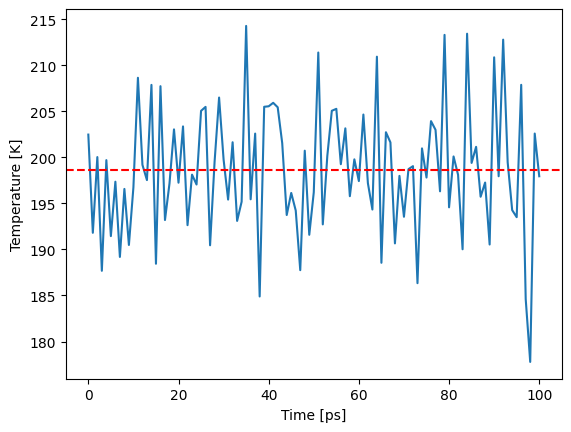

In [20]:
plt.plot(result["steps"]*1e-3, result["temperature"])
plt.axhline(np.mean(result["temperature"]), color="red", linestyle="--")
plt.xlabel("Time [ps]")
plt.ylabel("Temperature [K]");

In [21]:
print(result["structure"])

Atoms(symbols='Al100Ca50O400Si100', pbc=True, cell=[[20.20930767894279, 3.7123895943001964e-15, 3.712389594300197e-15], [-2.474926396084673e-15, 20.209307678, 3.712389594127009e-15], [-2.4749263960846723e-15, -2.4749263960846727e-15, 20.209307678]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)


In [22]:
# NBVAL_CHECK_OUTPUT

from ase import units

V = np.mean(result["generic"]["volume"])*1e-24 # volume in cm#
massTot = result["structure"].get_masses().sum()/units._Nav

density = massTot/V
print(f"{(massTot/V):.2f} g/cm3") 

2.80 g/cm3
